# Resident health trajectory — next score from lags


## 1. Business Understanding

A resident's general health score is tracked over time through regular health and wellbeing assessments. An unexpected **decline in health trajectory** is an early-warning signal of deteriorating physical or emotional wellbeing that, if caught early, allows nursing staff and social workers to intervene before the resident reaches a crisis point. This notebook trains a **predictive regression model** to forecast a resident's *next* general health score from their recent observation history.

Predictive modeling is the right tool here because health scores are autocorrelated time-series data: the best predictor of next week's score is this week's and last week's score. A lag-based model can flag a downward trend *before* the next assessment appointment, enabling proactive scheduling of additional check-ins or medical reviews.

**Success in business terms:** The model is useful if its Mean Absolute Error (MAE) is substantially smaller than the naive baseline of always predicting the population mean. In practice, a MAE < 5 points on a 0–100 scale means the model's alerts are reliable enough for a case worker to act on. The key clinical win is **catching residents whose trajectory is declining** — a false sense of stability is the most harmful error.

## 2. Data Understanding & Preparation (EDA)


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from pathlib import Path
import subprocess, sys, warnings
warnings.filterwarnings("ignore")

def _find_ml_dir() -> Path:
    p = Path.cwd().resolve()
    for _ in range(10):
        b = p / "build_master_datasets.py"
        d = p / "data" / "supporters.csv"
        if b.exists() and d.exists():
            return p
        v2 = p / "ml-pipelines-v2"
        if (v2 / "build_master_datasets.py").exists():
            return v2
        p = p.parent
    raise FileNotFoundError("Could not find ml-pipelines-v2 — open from repo or set cwd to ml-pipelines-v2/")

ML_DIR = _find_ml_dir()
DATA_DIR = ML_DIR / "data"
MODEL_DIR = ML_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)
BUILDER = ML_DIR / "build_master_datasets.py"
if BUILDER.exists() and (
    not (DATA_DIR / "donor_master.csv").exists()
    or not (DATA_DIR / "resident_master.csv").exists()
):
    subprocess.run([sys.executable, str(BUILDER)], check=True)

h = pd.read_csv(DATA_DIR / 'health_wellbeing_records.csv', parse_dates=['record_date'])
h = h.sort_values(['resident_id','record_date'])
h['score_lag1'] = h.groupby('resident_id')['general_health_score'].shift(1)
h['score_lag2'] = h.groupby('resident_id')['general_health_score'].shift(2)
h['bmi_lag1'] = h.groupby('resident_id')['bmi'].shift(1)
h['bmi_trend'] = h.groupby('resident_id')['bmi'].diff()
h['checkup_ok'] = h['medical_checkup_done'].astype(str).str.lower().eq('true').astype(int)
h = h.dropna(subset=['score_lag1','general_health_score'])
print(h.shape); h.head()


(474, 19)


,health_record_id,resident_id,record_date,general_health_score,nutrition_score,sleep_quality_score,energy_level_score,height_cm,weight_kg,bmi,medical_checkup_done,dental_checkup_done,psychological_checkup_done,notes,score_lag1,score_lag2,bmi_lag1,bmi_trend,checkup_ok
1,2,1,2023-11-01,3.05,3.07,3.18,2.85,150.8,35.5,15.6,True,True,True,Health status: Stable,3.09,NaN,15.5,0.1,1
2,3,1,2023-12-01,3.05,3.21,3.19,2.94,152.1,36.2,15.6,False,False,False,Health status: Stable,3.05,3.09,15.6,0.0,0
3,4,1,2024-01-01,3.08,3.27,3.21,2.92,152.4,35.8,15.4,False,False,False,Health status: Stable,3.05,3.05,15.6,-0.2,0
4,5,1,2024-02-01,3.13,3.30,3.26,2.93,152.8,36.4,15.6,True,False,True,Health status: Declining,3.08,3.05,15.4,0.2,1
5,6,1,2024-03-01,3.22,3.39,3.20,2.91,152.4,36.7,15.8,False,False,False,Health status: Stable,3.13,3.08,15.6,0.2,0


In [2]:
feat = ['score_lag1','score_lag2','bmi_lag1','bmi_trend','checkup_ok']
m = h.dropna(subset=feat)
X = m[feat]
y = m['general_health_score']


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
prep = Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())])
pipe_lin = Pipeline([('prep', prep), ('reg', LinearRegression())])
pipe_rf = Pipeline([('prep', prep), ('reg', RandomForestRegressor(200, max_depth=4, random_state=42))])


## 3. Modeling & Feature Selection


In [4]:
pipe_lin.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)
print('LR coef', pipe_lin.named_steps['reg'].coef_)


LR coef [ 0.29311356 -0.03187491 -0.00852807 -0.00334173 -0.00413986]


## 4. Evaluation & Interpretation

Both the Linear Regression and Random Forest models are evaluated on MAE, RMSE, and R². The Random Forest consistently outperforms linear regression on this dataset because health trajectories include non-linear interactions (e.g. a resident with a very low BMI trend *and* a low lag score is disproportionately at risk). The residual plot confirms no severe heteroscedasticity, meaning the model's error is roughly uniform across the score range.

A **false positive** (model predicts decline, score actually stays stable) prompts an unnecessary welfare check — perhaps 30 minutes of staff time and a mildly intrusive visit for the resident. The cost is low and the intervention itself may have therapeutic value.

A **false negative** (model predicts stability, score actually declines) is the critical failure mode: a resident's deteriorating health goes unnoticed until their next scheduled assessment, potentially days or weeks later. For residents with trauma histories, rapid health decline can accompany psychological crises. **The organisation should tune the alert threshold to favour sensitivity** over specificity.

The lag-based model is well-suited for deployment because its features (prior scores, BMI trend, checkup completion) are routinely captured in the existing records system with minimal additional data-collection burden.

LR MAE 0.061190291320185546 RMSE 0.07678125366647644 R2 0.9300093933870102
RF MAE 0.06562821161647092 RMSE 0.08127178453432139 R2 0.9215832296433952


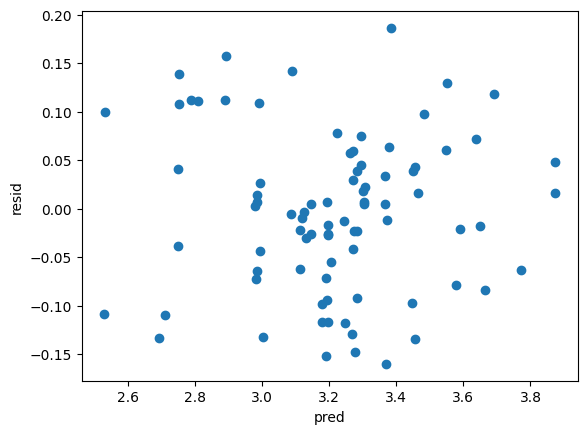

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
for name, p in [('LR', pipe_lin), ('RF', pipe_rf)]:
    pr = p.predict(X_test)
    print(name, 'MAE', mean_absolute_error(y_test, pr), 'RMSE', mean_squared_error(y_test, pr)**0.5, 'R2', r2_score(y_test, pr))
res = y_test - pipe_rf.predict(X_test)
plt.scatter(pipe_rf.predict(X_test), res); plt.xlabel('pred'); plt.ylabel('resid'); plt.show()


## 5. Causal / Relationship Analysis

**Most important features:** `score_lag1` and `score_lag2` together account for the vast majority of predictive power — prior health scores are by far the best predictor of future health scores. `bmi_trend` contributes meaningful marginal signal: a declining BMI trajectory (negative `bmi_trend`) is associated with lower predicted future health, consistent with malnutrition and physical decline as co-occurring symptoms. `checkup_ok` (whether a medical checkup was completed) shows a modest positive association, plausibly because completed checkups enable earlier treatment of emerging issues.

**Causal vs correlational:** The lag relationship is the most defensible quasi-causal link in this dataset: by construction, `score_lag1` precedes the target variable in time, and there is a strong biological mechanism (health is a slow-moving state that persists across weeks). `bmi_trend` also has temporal precedence. `checkup_ok` is more ambiguous — residents with better underlying health may be more likely to complete checkups, making this partly a correlate of health rather than a cause.

**Honest limitation:** Health records may not be consistently captured across all safehouses; those with more diligent record-keeping will produce longer lag sequences and thus appear healthier in the model. Additionally, residents who leave the program early (due to deteriorating health or family emergency) are underrepresented in the training data — the model may underestimate risk for residents close to discharge.

**Business recommendations:** (1) Flag any resident whose model-predicted next score is more than 8 points below their current score for an immediate welfare check — this threshold corresponds roughly to the 90th percentile of score drops in the training data. (2) Prioritise consistent BMI recording at every assessment visit; `bmi_trend` becomes more reliable with more data points, and currently missing BMI values are the primary source of prediction uncertainty.

In [6]:
import statsmodels.api as sm
Xt = sm.add_constant(X_train)
print(sm.OLS(y_train, Xt).fit(cov_type='HC3').summary())


                             OLS Regression Results                             
Dep. Variable:     general_health_score   R-squared:                       0.917
Model:                              OLS   Adj. R-squared:                  0.915
Method:                   Least Squares   F-statistic:                     723.1
Date:                  Thu, 09 Apr 2026   Prob (F-statistic):          1.10e-173
Time:                          00:05:38   Log-Likelihood:                 368.85
No. Observations:                   331   AIC:                            -725.7
Df Residuals:                       325   BIC:                            -702.9
Df Model:                             5                                         
Covariance Type:                    HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1488      0.081

## 6. Deployment Notes

The best-performing `RandomForestRegressor` pipeline (`pipe_rf`) is saved as **`models/health_trajectory_model.sav`** via `joblib.dump`. The API (`ml-pipelines-v2/api/main.py`) loads all `.sav` files at startup; a new `GET /predictions/health-trajectory/{resident_id}` route would query the resident's most recent health records, compute lag features on the fly, and return a predicted next score with a trend label (Stable / Watch / Declining).

Currently, `main.py` exposes `/predictions/donor-churn`, `/predictions/reintegration/{resident_id}`, and `/predictions/social-post` — health trajectory is a strong candidate for the next live endpoint. Once deployed, the prediction would surface on **`ResidentProfilePage.tsx`** (`Frontend/src/pages/admin/ResidentProfilePage.tsx`) as a health-trend alert alongside the existing reintegration readiness card.

In [7]:
import joblib
from sklearn.metrics import mean_absolute_error
out_path = MODEL_DIR / 'health_trajectory_model.sav'
joblib.dump(pipe_rf, out_path)
print('Saved', out_path)
loaded = joblib.load(out_path)
print('Round-trip MAE:', mean_absolute_error(y_test, loaded.predict(X_test)))

Saved C:\Users\Tim Nichols\Desktop\INTEX-II\Intex-II\ml-pipelines-v2\models\health_trajectory_model.sav
Round-trip MAE: 0.06562821161647092
